- To identify and note down features contributing to HR data patterns
- To identify relation between various attributes toward HR data pattern behaviors

In [4]:
import pandas as pd

df = pd.read_csv("..\\datasets\\WA_Fn-UseC_-HR-Employee-Attrition.csv")

In [5]:
print(df.shape)
print(df.isna().sum())
print(df.dtypes)

(1470, 35)
Age                         0
Attrition                   0
BusinessTravel              0
DailyRate                   0
Department                  0
DistanceFromHome            0
Education                   0
EducationField              0
EmployeeCount               0
EmployeeNumber              0
EnvironmentSatisfaction     0
Gender                      0
HourlyRate                  0
JobInvolvement              0
JobLevel                    0
JobRole                     0
JobSatisfaction             0
MaritalStatus               0
MonthlyIncome               0
MonthlyRate                 0
NumCompaniesWorked          0
Over18                      0
OverTime                    0
PercentSalaryHike           0
PerformanceRating           0
RelationshipSatisfaction    0
StandardHours               0
StockOptionLevel            0
TotalWorkingYears           0
TrainingTimesLastYear       0
WorkLifeBalance             0
YearsAtCompany              0
YearsInCurrentRole          0

In [8]:
df["Attrition_bool"] = df["Attrition"].map({"Yes": 1, "No": 0})
df["Attrition_bool"].value_counts(normalize=True)

Attrition_bool
0    0.838776
1    0.161224
Name: proportion, dtype: float64

Attrition ratio : 84:16

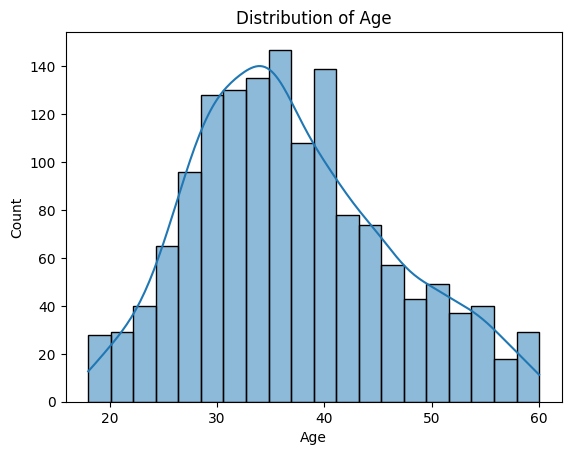

In [9]:
# Distribution chart of Age
import seaborn as sns
import matplotlib.pyplot as plt

sns.histplot(data=df, x="Age", bins=20, kde=True)
plt.xlabel("Age")
plt.ylabel("Count")
plt.title("Distribution of Age")
plt.show()

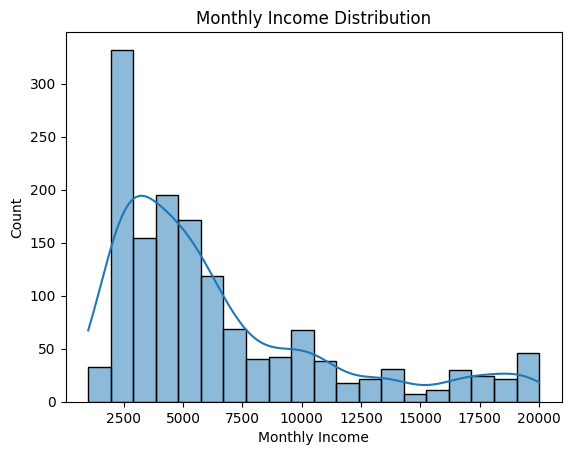

In [12]:
# Monthly income distribution
sns.histplot(data=df, x="MonthlyIncome", bins=20, kde=True)
plt.xlabel("Monthly Income")
plt.ylabel("Count")
plt.title("Monthly Income Distribution")
plt.show()

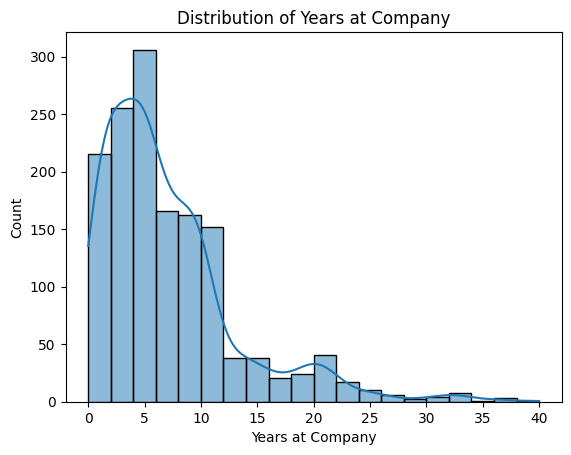

In [13]:
# Distribution by years at company
sns.histplot(data=df, x="YearsAtCompany", bins=20, kde=True)
plt.xlabel("Years at Company")
plt.ylabel("Count")
plt.title("Distribution of Years at Company")
plt.show()

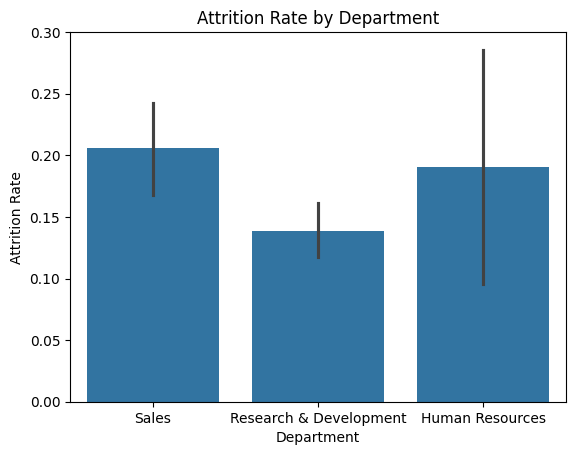

In [14]:
# Attrition rate by department
sns.barplot(data=df, x="Department", y="Attrition_bool")
plt.xlabel("Department")
plt.ylabel("Attrition Rate")
plt.title("Attrition Rate by Department")
plt.show()

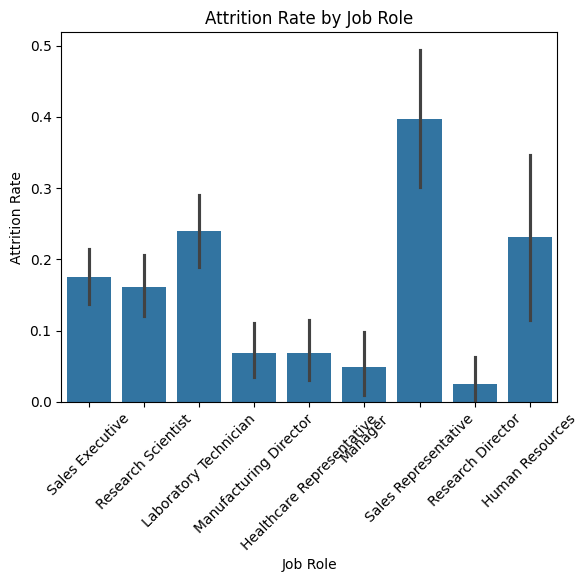

In [18]:
# Attrition Rate by Job Role
sns.barplot(data=df, x="JobRole", y="Attrition_bool")
plt.xlabel("Job Role")
plt.ylabel("Attrition Rate")
plt.title("Attrition Rate by Job Role")
plt.xticks(rotation=45)
plt.show()

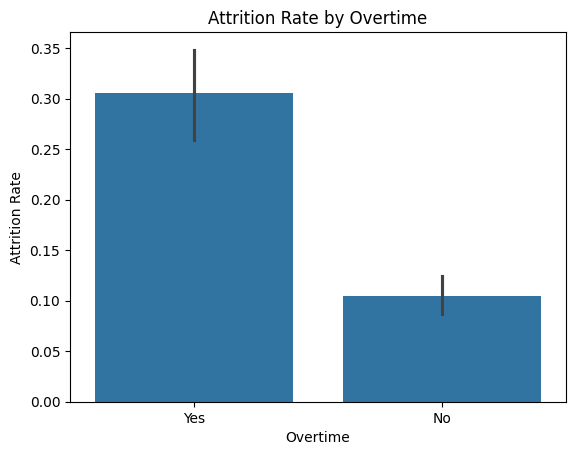

In [19]:
# Attrition rate by Overtime
sns.barplot(data=df, x="OverTime", y="Attrition_bool")
plt.xlabel("Overtime")
plt.ylabel("Attrition Rate")
plt.title("Attrition Rate by Overtime")
plt.show()

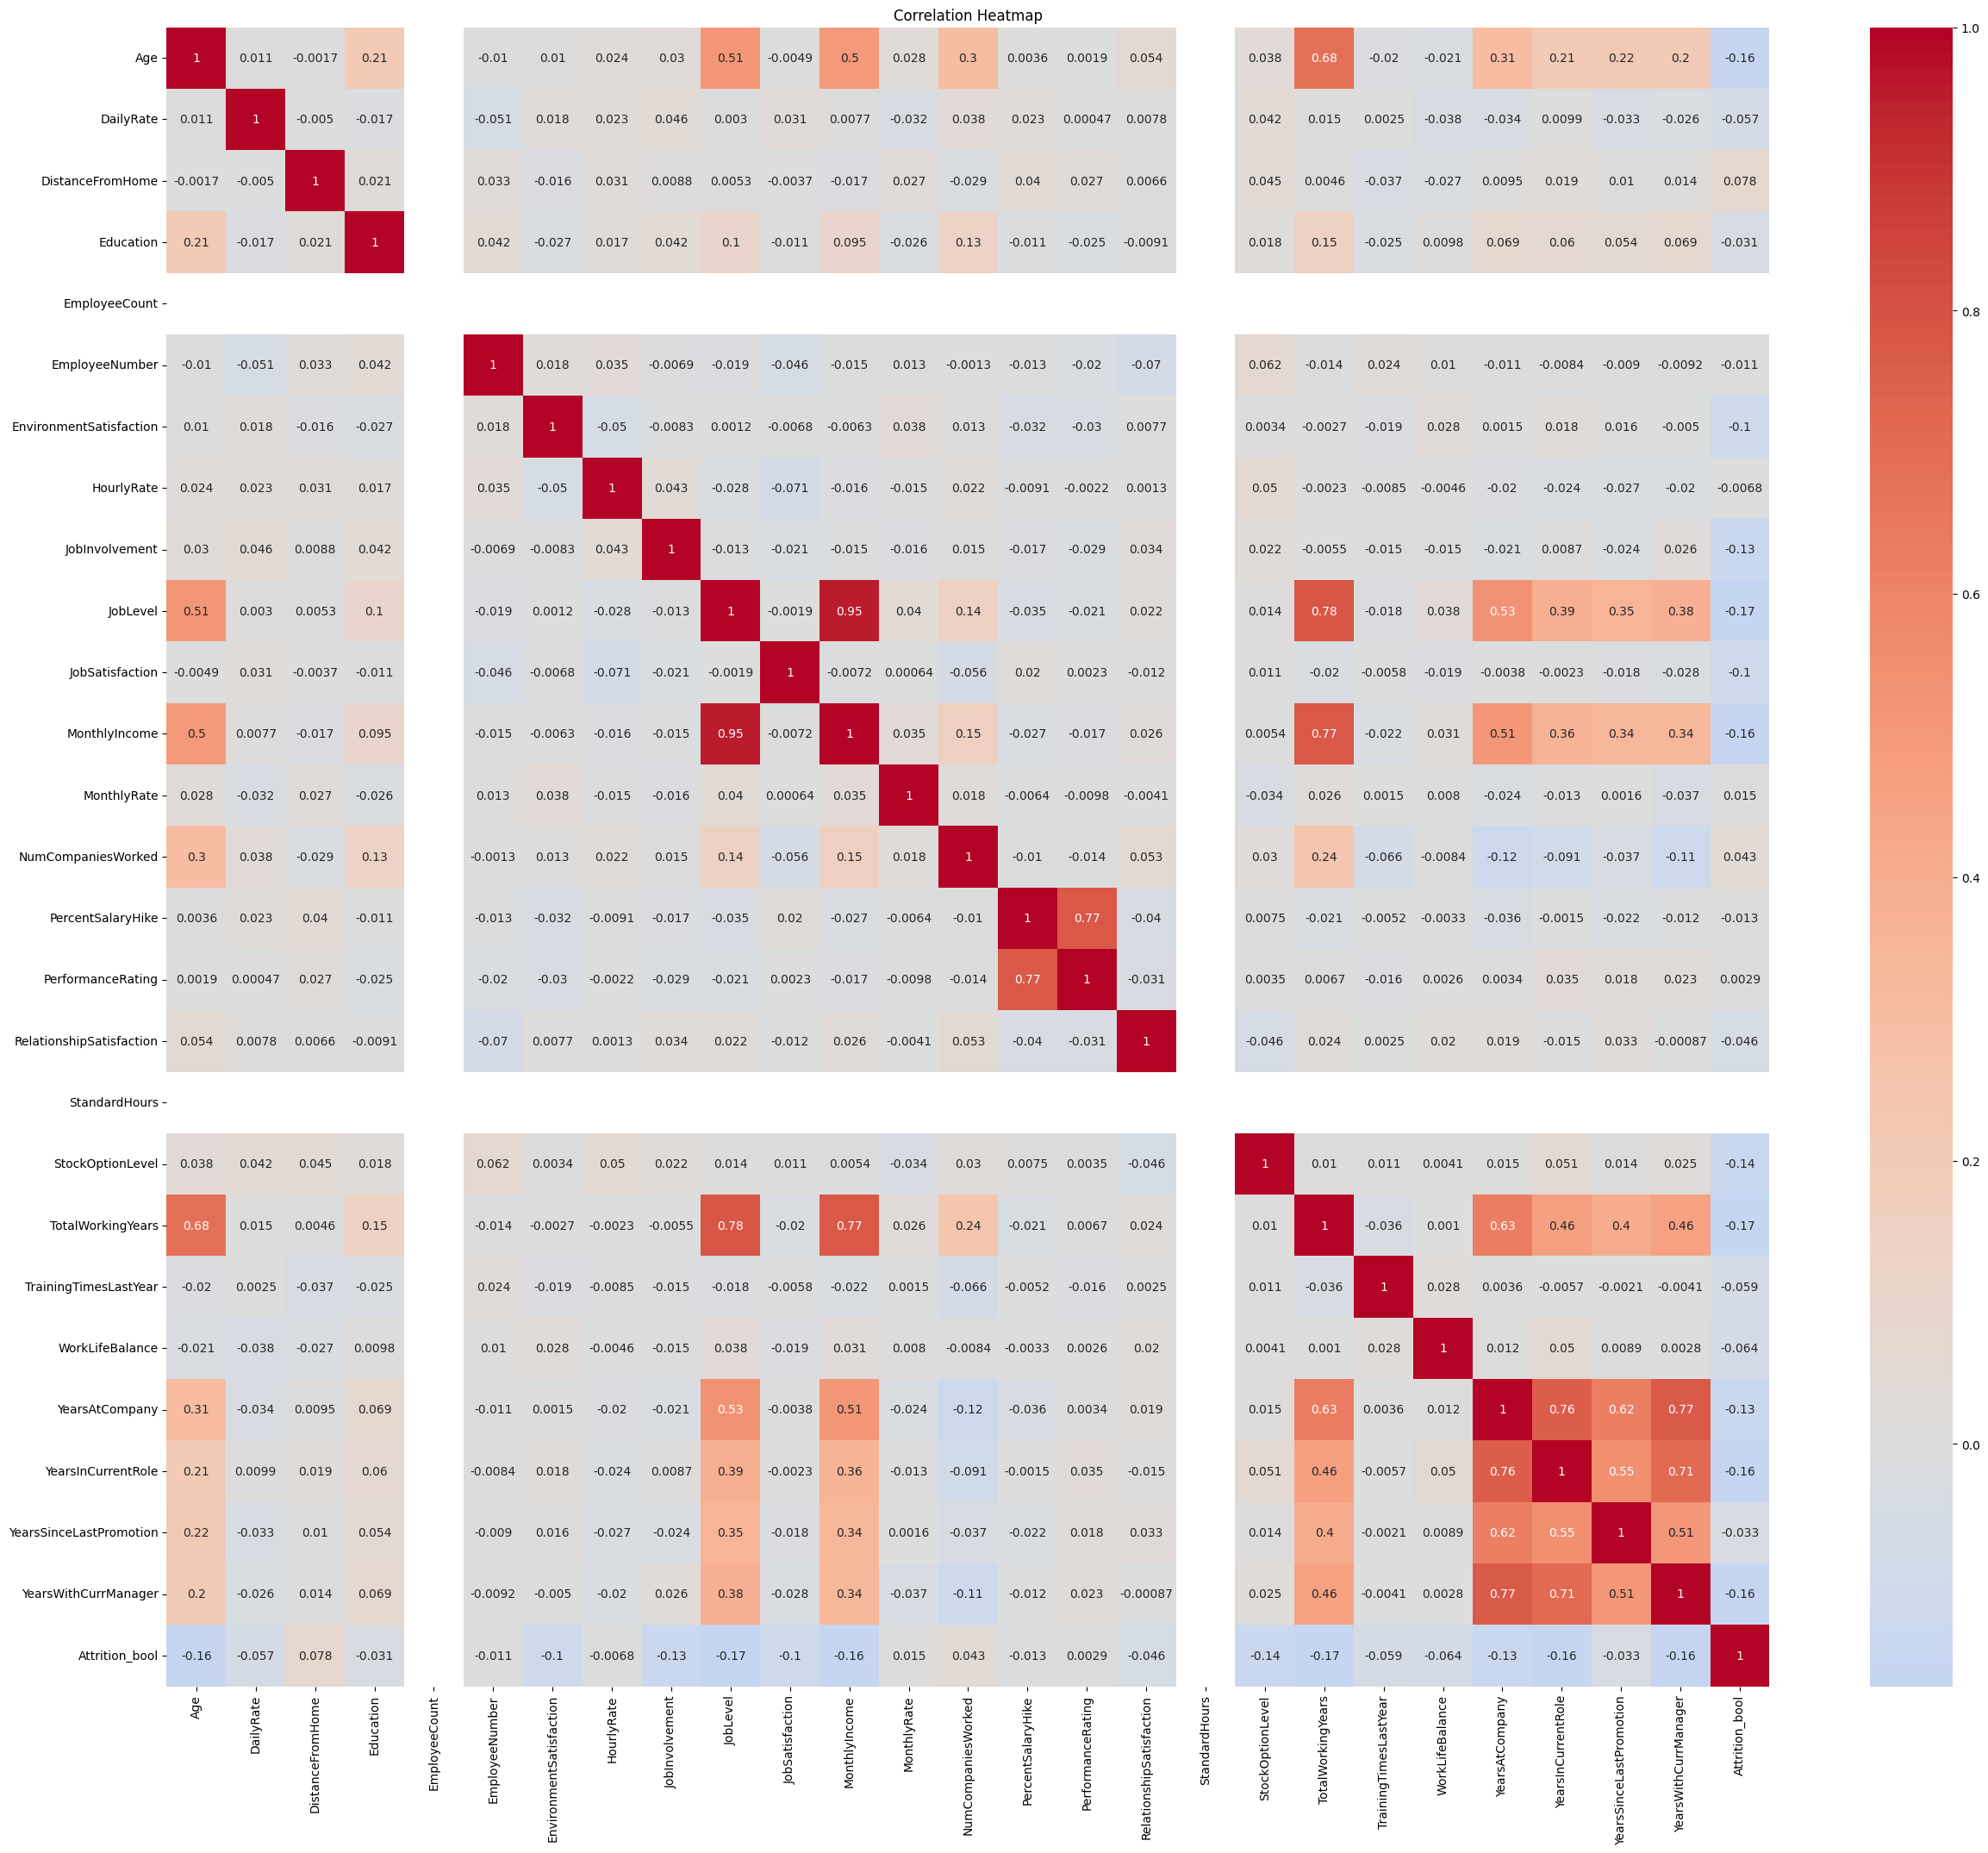

In [26]:
# correlation heatmap
plt.figure(figsize=(30, 25))
sns.heatmap(df.select_dtypes(exclude=['str']).corr(), annot=True, cmap="coolwarm", center=0)
plt.title("Correlation Heatmap")
plt.show()

Key insights from the recent charts:

- **Age distribution:** Most employees are concentrated in the mid-career range, with fewer very young or older employees.
- **Monthly income:** Income is right-skewed, meaning most employees earn on the lower-to-middle end, with a smaller group earning much more.
- **Years at company:** Many employees have relatively few years at the company, suggesting a large early-tenure population.
- **Attrition by department:** Attrition tends to differ by department, with one or more departments showing higher turnover than others.
- **Attrition by job role:** Some roles have noticeably higher attrition, indicating role-specific retention issues.
- **Attrition by overtime:** Employees with **overtime = Yes** usually show much higher attrition, making overtime a strong risk signal.
- **Correlation heatmap:**  
    - **MonthlyIncome** and **JobLevel** typically move together strongly.  
    - **TotalWorkingYears**, **YearsAtCompany**, **YearsInCurrentRole**, and **YearsWithCurrManager** are usually positively correlated.  
    - **Attrition_bool** often shows negative relation with **income**, **job level**, and **tenure-related variables**.

Overall, attrition appears more common among employees who are newer, lower-paid, and working overtime.

The following columns matter in business perspective

- DistanceFromHome - How long an employee commutes to work matters
- jobLevel - lower level employees tend to have less loyalty and more mobility
- NumCompaniesWorked - job hoppers tend to keep hopping 
- MonthlyIncome - No need to explain
- YearsAtCompany - tenure patterns are real

These are important too:
- employmentSatisfaction
- jobInvolvement
- jobSatisfaction
- Worklifebalance
- Overtime